# HNOCA Dataset Investigation
## Load Dataset

In [1]:
import pandas as pd
import scanpy as sc
from utils.io import read_anndata
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dask import array as da
from tqdm.dask import TqdmCallback

from utils.cellxgene import get_cxg_url
from utils.io import read_anndata


url = get_cxg_url(
    collection_id="de379e5f-52d0-498c-9801-0f850823c847",
    dataset_id="3a805b8d-c9d8-4c9b-881f-0eefa635974d"
)

dataset_name = 'He2024'
file_path = f'data/{dataset_name}.h5ad'

if not Path(file_path).exists():
    !curl {url} > {file_path}


adata = read_anndata(
    file_path,
    X='X',
    obs='obs',
    var='var',
    obsm='obsm',
)

/Users/seohyon/miniconda3/envs/scanpy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Get URL for CxG collection ID "de379e5f-52d0-498c-9801-0f850823c847" and dataset ID "3a805b8d-c9d8-4c9b-881f-0eefa635974d"
URL: https://datasets.cellxgene.cziscience.com/77fef2d8-d317-4b6c-b041-174510dc1e00.h5ad
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 17.5G  100 17.5G    0     0  22.3M      0  0:13:23  0:13:23 --:--:-- 14.1M
dask: False, backed: False
Read slot "X", store as "X"...
Read slot "obs", store as "obs"...
Read slot "var", store as "var"...
Read slot "obsm", store as "obsm"...


## Dataset Complexity
### Tissues

In [7]:
adata.obs["tissue"].unique()

['hindbrain', 'telencephalon', 'cerebral cortex', 'ventral part of telencephalon', 'midbrain tegmentum', ..., 'arcuate nucleus of hypothalamus', 'choroid plexus', 'cerebellum', 'midbrain tectum', 'dorsal plus ventral thalamus']
Length: 11
Categories (11, object): ['arcuate nucleus of hypothalamus', 'brain', 'cerebellum', 'cerebral cortex', ..., 'midbrain tectum', 'midbrain tegmentum', 'telencephalon', 'ventral part of telencephalon']

Sample size of the tissues:

In [8]:
sample_size = adata.obs["tissue"].value_counts()
sample_size

tissue
telencephalon                      802509
cerebral cortex                    353984
brain                              287461
midbrain tegmentum                 156397
midbrain tectum                     59980
arcuate nucleus of hypothalamus     26693
ventral part of telencephalon       23517
hindbrain                           16703
choroid plexus                      15577
cerebellum                          14285
dorsal plus ventral thalamus        10568
Name: count, dtype: int64

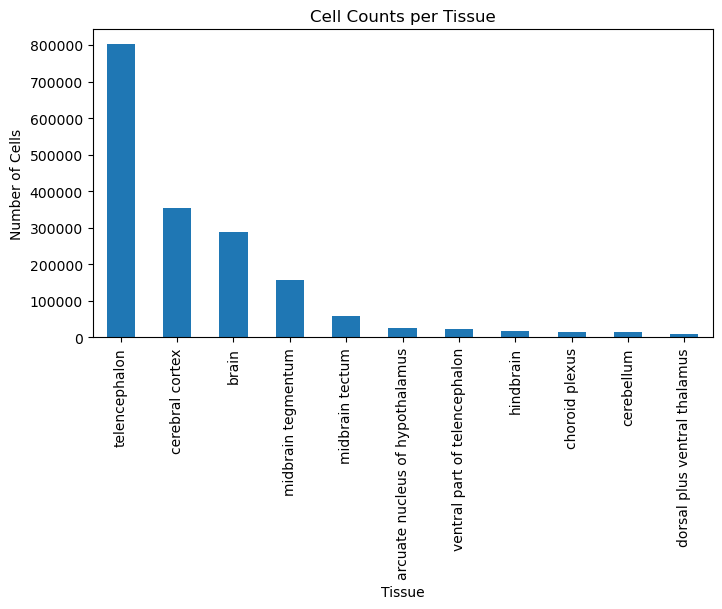

In [11]:
plt.figure(figsize=(8, 4))
sample_size.plot(kind='bar')
plt.title("Cell Counts per Tissue")
plt.xlabel("Tissue")
plt.xticks(rotation=90)
plt.ylabel("Number of Cells")
plt.show()

### Number of Cells and Genes

In [12]:
adata

AnnData object with n_obs × n_vars = 1767674 × 36720
    obs: 'assay_differentiation', 'assay_type_differentiation', 'bio_sample', 'cell_line', 'cell_type_original', 'gm', 'id', 'individual', 'state_exact', 'suspension_type', 'tech_sample', 'treatment', 'organoid_age_days', 'publication', 'doi', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'annot_level_1', 'annot_level_2', 'annot_level_3_rev2', 'annot_level_4_rev2', 'annot_region_rev2', 'annot_ntt_rev2', 'Hallmark_Glycolysis', 'tissue_type', 'sex_ontology_term_id', 'donor_id', 'assay_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'mt', 'n_cells_b

### Number of Cell Types

In [14]:
adata.obs["cell_type"].nunique()

61

## Batch Complexity
### Number of Batches

batch = concatenation of the dataset identifier (annotation column ‘id’), the annotation of biological replicates (annotation column ‘bio_sample’) as well as technical replicates (annotation column ‘tech_sample’)

In [17]:
adata.obs["batch"].nunique()

396

### Batch Size Imbalance

In [18]:
batch_size = adata.obs["batch"].value_counts().sort_values(ascending=False)
mean = np.mean(batch_size)
std = np.std(batch_size)
min_val = batch_size.min()
max_val = batch_size.max()
print(f"Mean batch size: {mean:.2f}")
print(f"Standard deviation: {std:.2f}")
print(f"Minimum batch size: {min_val}")
print(f"Maximum batch size: {max_val}")

Mean batch size: 4463.82
Standard deviation: 3177.69
Minimum batch size: 1
Maximum batch size: 19300
